# Tahap 2 - Evaluasi & Inference Pipeline

Mengukur seberapa layak adapter LoRA hasil `finetune_qlora.ipynb` dipakai di produksi.

Yang dihitung di notebook ini:

| Metrik | Arti | Target |
|---|---|---|
| **Schema Validity Rate** | % output yang lolos `json.loads` + validasi Pydantic | > 98 % |
| **Jumlah & jenis error** | JSON rusak / field hilang / tipe salah / output kosong | sekecil mungkin |
| **MAE per field** | rata-rata selisih absolut angka prediksi vs ground truth | < 1 cm |
| **Error count per toleransi** | berapa sampel meleset > 0.5 cm dan > 1.0 cm | - |
| **Akurasi kategorikal** | jenis furnitur, material, finish, boolean | - |
| **Off-by-N partisi** | distribusi salah hitung ambalan/pintu/laci | - |
| **Dampak hilir** | selisih part list BOM & jumlah lembar triplek | - |
| **Gold test** | foto sketsa nyata dari bengkel | lolos manual |

Logika metriknya ada di [`evaluate.py`](evaluate.py); notebook ini hanya menjalankan dan
memvisualkannya supaya bisa diulang tanpa menyalin kode.

## 1. Konfigurasi

In [1]:
from pathlib import Path
import json, sys

BASE_DIR   = Path.cwd()                       # folder "AI Services"
sys.path.insert(0, str(BASE_DIR))             # supaya modul .py di folder ini bisa di-import

DATA_DIR    = BASE_DIR / "dataset_generator" / "synthetic_furniture_dataset_v2"
VAL_FILE    = DATA_DIR / "val.jsonl"
OUTPUT_DIR  = BASE_DIR / "outputs" / "qwen2vl-2b-nesto-lora"
ADAPTER_DIR = OUTPUT_DIR / "adapter"
PRED_FILE   = OUTPUT_DIR / "val_predictions.jsonl"    # cache hasil inference
REPORT_JSON = OUTPUT_DIR / "eval_report.json"

MODEL_ID   = "Qwen/Qwen2-VL-2B-Instruct"
# HARUS sama persis dengan MIN/MAX_PIXELS di finetune_qlora.ipynb. Evaluasi pada
# resolusi lebih rendah dari training membuat angka pada sketsa terbaca lebih kabur
# daripada saat dilatih, dan skornya jatuh tanpa sebab yang berhubungan dengan model.
MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 1024 * 28 * 28

# ---------- Tombol ----------
LIMIT          = None     # jumlah sampel validasi yang dievaluasi (None = semua 300)
RUN_INFERENCE  = True    # False = pakai PRED_FILE yang sudah ada (tanpa GPU)
BATCH_SIZE     = 2       # naikkan kalau VRAM sisa banyak
MAX_NEW_TOKENS = 320
WITH_NESTING   = True    # ikut hitung selisih jumlah lembar triplek (lebih lambat)

print("adapter :", ADAPTER_DIR, "->", "ADA" if ADAPTER_DIR.exists() else "TIDAK ADA")
print("val set :", VAL_FILE, "->", "ADA" if VAL_FILE.exists() else "TIDAK ADA")
print("cache   :", PRED_FILE, "->", "ADA" if PRED_FILE.exists() else "belum ada")

# Cache prediksi tidak menyimpan jejak adapter mana yang membuatnya. Kalau adapter
# lebih baru dari cache, laporan di bawah menilai model LAMA - ini pernah terjadi.
if PRED_FILE.exists() and ADAPTER_DIR.exists():
    import datetime as _dt
    t_pred = PRED_FILE.stat().st_mtime
    t_adap = max(f.stat().st_mtime for f in ADAPTER_DIR.rglob("*") if f.is_file())
    fmt = lambda t: _dt.datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M")
    print()
    print(f"adapter dilatih : {fmt(t_adap)}")
    print(f"cache prediksi  : {fmt(t_pred)}")
    if t_adap > t_pred:
        print("PERINGATAN: adapter lebih baru dari cache prediksi. "
              "Set RUN_INFERENCE = True, kalau tidak yang dievaluasi adalah model lama.")

adapter : d:\Codelabs\TukangKayu\Nesto.ai\AI Services\outputs\qwen2vl-2b-nesto-lora\adapter -> ADA
val set : d:\Codelabs\TukangKayu\Nesto.ai\AI Services\dataset_generator\synthetic_furniture_dataset_v2\val.jsonl -> ADA
cache   : d:\Codelabs\TukangKayu\Nesto.ai\AI Services\outputs\qwen2vl-2b-nesto-lora\val_predictions.jsonl -> ADA

adapter dilatih : 2026-08-24 11:33
cache prediksi  : 2026-08-24 03:50
PERINGATAN: adapter lebih baru dari cache prediksi. Set RUN_INFERENCE = True, kalau tidak yang dievaluasi adalah model lama.


## 2. Muat set validasi

`load_eval_set` mengembalikan tiga hal:
- `rows`  - baris mentah `val.jsonl` (dipakai untuk inference)
- `refs`  - `{id: dict ground truth}`
- `meta`  - `{id: {"layout": ..., "decimal_comma": ...}}` untuk breakdown per layout

In [2]:
import evaluate as ev
from importlib import reload
reload(ev)     # jalankan ulang cell ini kalau evaluate.py diedit

rows, refs, meta = ev.load_eval_set(VAL_FILE, DATA_DIR, limit=LIMIT)
print(f"{len(rows)} sampel dimuat, {len(refs)} punya ground truth")

from collections import Counter
print("Sebaran furniture_type :", dict(Counter(r["furniture_type"] for r in refs.values())))
print("Sebaran layout         :", dict(Counter(m.get("layout") for m in meta.values())))
print("\nContoh ground truth:")
print(json.dumps(next(iter(refs.values())), indent=2)[:600])

300 sampel dimuat, 300 punya ground truth
Sebaran furniture_type : {'reception_desk': 100, 'nightstand': 31, 'base_cabinet': 88, 'bookshelf': 81}
Sebaran layout         : {'isometric': 159, 'multiview_2d': 141}

Contoh ground truth:
{
  "furniture_type": "reception_desk",
  "overall_dimensions": {
    "length_cm": 178.7,
    "width_cm": 54.7,
    "height_cm": 90.2
  },
  "plinth": {
    "has_plinth": true,
    "height_cm": 8.5,
    "offset_cm": 4.6
  },
  "partitions": {
    "shelves_count": 0,
    "doors_count": 0,
    "drawers_count": 0
  },
  "material": {
    "board_material": "MDF",
    "board_thickness_mm": 12,
    "finish": "Duco",
    "finish_color": null,
    "finish_code": null
  },
  "drop_pocket": null,
  "has_curve": true,
  "default_thickness_mm": 18,
  "default_edging_mm": 1.0
}


## 3. Inference

Model base 4-bit + adapter LoRA. `padding_side="left"` wajib untuk generate
(kalau kanan, token jawaban tercampur padding dan hasilnya kacau).
`do_sample=False` (greedy) supaya evaluasi deterministik dan bisa diulang.

In [3]:
import time

if RUN_INFERENCE:
    t0 = time.time()
    model, processor = ev.load_model(ADAPTER_DIR, MODEL_ID, MIN_PIXELS, MAX_PIXELS)
    print(f"model siap dalam {time.time() - t0:.1f} s")

    t0 = time.time()
    preds = ev.generate_predictions(
        rows, DATA_DIR, model, processor, MIN_PIXELS, MAX_PIXELS,
        max_new_tokens=MAX_NEW_TOKENS, batch_size=BATCH_SIZE,
    )
    dt = time.time() - t0
    print(f"{len(preds)} prediksi dalam {dt:.1f} s ({dt / max(len(preds), 1):.2f} s/sampel)")

    PRED_FILE.parent.mkdir(parents=True, exist_ok=True)
    ev.save_predictions(preds, PRED_FILE)
    print("disimpan di", PRED_FILE)
else:
    preds = ev.load_predictions(PRED_FILE)
    print(f"{len(preds)} prediksi dimuat dari cache {PRED_FILE}")

print("\n--- contoh output mentah model ---")
if preds:
    sid = next(iter(preds))
    print(sid, "->", preds[sid][:400])
else:
    print("TIDAK ADA prediksi sama sekali - cek path gambar dan ADAPTER_DIR.")

d:\Codelabs\TukangKayu\Nesto.ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 729/729 [00:06<00:00, 112.67it/s]


model siap dalam 28.3 s
  inference 300/300
300 prediksi dalam 1989.1 s (6.63 s/sampel)
disimpan di d:\Codelabs\TukangKayu\Nesto.ai\AI Services\outputs\qwen2vl-2b-nesto-lora\val_predictions.jsonl

--- contoh output mentah model ---
synth_1095 -> {"furniture_type":"reception_desk","overall_dimensions":{"length_cm":178.7,"width_cm":54.7,"height_cm":90.2},"plinth":{"has_plinth":true,"height_cm":8.5,"offset_cm":4.6},"partitions":{"shelves_count":0,"doors_count":0,"drawers_count":0},"material":{"board_material":"MDF","board_thickness_mm":12,"finish":"Duco","finish_color":null,"finish_code":null},"drop_pocket":null,"has_curve":true,"default_thi


## 4. Laporan lengkap

Satu panggilan `evaluate()` menghasilkan seluruh metrik; `format_report()` mencetaknya
sebagai laporan teks yang bisa langsung ditempel di catatan rilis.

In [4]:
# Cache prediksi bisa memuat lebih sedikit sampel daripada set validasi (sisa run
# dengan LIMIT kecil, atau inference yang terhenti). evaluate() hanya menilai sampel
# yang punya prediksi, jadi denominatornya diam-diam mengecil kalau tidak dicek.
n_dinilai = len(set(preds) & set(refs))
if n_dinilai < len(refs):
    print(f"PERINGATAN: hanya {n_dinilai} dari {len(refs)} sampel validasi punya "
          f"prediksi. Laporan di bawah TIDAK mewakili seluruh set validasi - "
          f"jalankan ulang inference dengan LIMIT = None.")

report = ev.evaluate(preds, refs, meta, downstream=True, nest=WITH_NESTING, worst_k=10)
print(ev.format_report(report))

REPORT_JSON.write_text(json.dumps(report.to_dict(), indent=2, ensure_ascii=False), encoding="utf-8")
print("Laporan JSON ->", REPORT_JSON)

LAPORAN EVALUASI MODEL EKSTRAKSI SKETSA -> JSON
Sampel dievaluasi        : 300
Output valid (skema OK)  : 300
Output GAGAL             : 0
Schema Validity Rate     : 100.00 %  (target > 98%) -> LULUS

MEAN ABSOLUTE ERROR - FIELD NUMERIK (satuan mengikuti nama field)
field                                 n      MAE    MedAE     RMSE      max   >tol     acc%     tol
---------------------------------------------------------------------------------------------------
overall_dimensions.length_cm        300    0.000    0.000    0.000    0.000      0   100.00 +-1.0cm
overall_dimensions.width_cm         300    0.000    0.000    0.000    0.000      0   100.00 +-1.0cm
overall_dimensions.height_cm        300    0.000    0.000    0.000    0.000      0   100.00 +-1.0cm
plinth.height_cm                    300    0.000    0.000    0.000    0.000      0   100.00 +-1.0cm
plinth.offset_cm                    300    0.004    0.000    0.045    0.600      0   100.00 +-1.0cm
drop_pocket.length_cm            

## 5. Schema Validity Rate & rincian error

Angka tunggal tidak cukup: yang penting adalah **berapa banyak** output gagal dan
**karena apa**. Empat jenis kegagalan yang dibedakan:

- `json_decode` - teks bukan JSON valid (paling sering: kepotong `max_new_tokens`)
- `schema`      - JSON valid tapi field hilang / tipe salah
- `empty`       - model tidak mengeluarkan apa pun
- lainnya       - exception tak terduga

In [5]:
import matplotlib.pyplot as plt

print(f"Total sampel        : {report.n_total}")
print(f"Valid               : {report.n_valid}")
print(f"Gagal               : {report.n_invalid}")
print(f"Schema Validity Rate: {report.schema_validity_rate:.2f} %  (target > 98 %)")
print("Status              :", "LULUS" if report.schema_validity_rate > 98 else "BELUM LULUS")

if report.n_invalid:
    kinds = dict(report.parse_errors)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].bar(list(kinds), list(kinds.values()), color="#d98c8c")
    ax[0].set_title("Jumlah error per jenis")
    ax[0].set_ylabel("sampel")
    for i, v in enumerate(kinds.values()):
        ax[0].text(i, v, str(v), ha="center", va="bottom")

    top = report.field_error_counter.most_common(8)
    if top:
        ax[1].barh([k for k, _ in top][::-1], [v for _, v in top][::-1], color="#e8b45f")
        ax[1].set_title("Field penyebab pelanggaran skema")
    plt.tight_layout(); plt.show()

    print("\nContoh output gagal:")
    for f in report.failures[:5]:
        print(f"  [{f['id']}] {f['error_kind']}: {f['detail']}")
        print(f"      {f['raw_preview']!r}\n")
else:
    print("\nTidak ada output yang gagal parse.")

Total sampel        : 300
Valid               : 300
Gagal               : 0
Schema Validity Rate: 100.00 %  (target > 98 %)
Status              : LULUS

Tidak ada output yang gagal parse.


## 6. MAE per field + jumlah sampel yang meleset

`n_error` pada kolom toleransi = **berapa sampel** yang selisihnya melebihi ambang.
Untuk tukang, meleset 0.4 cm masih bisa diakali; meleset > 1 cm berarti panel salah potong.

,n,MAE,MedAE,RMSE,max_err,bias,exact,toleransi,err_ketat,acc_ketat%,err_longgar,acc_longgar%,null_hilang,null_mengarang
field,,,,,,,,,,,,,,
overall_dimensions.length_cm,300,0.0000,0.0,0.0000,0.0,0.0000,300,+-0.5 / +-1.0 cm,0,100.00,0,100.0,0,0
overall_dimensions.width_cm,300,0.0000,0.0,0.0000,0.0,0.0000,300,+-0.5 / +-1.0 cm,0,100.00,0,100.0,0,0
overall_dimensions.height_cm,300,0.0000,0.0,0.0000,0.0,0.0000,300,+-0.5 / +-1.0 cm,0,100.00,0,100.0,0,0
plinth.height_cm,300,0.0000,0.0,0.0000,0.0,0.0000,300,+-0.5 / +-1.0 cm,0,100.00,0,100.0,0,0
plinth.offset_cm,300,0.0043,0.0,0.0451,0.6,-0.0043,297,+-0.5 / +-1.0 cm,1,99.67,0,100.0,0,0
drop_pocket.length_cm,72,0.0000,0.0,0.0000,0.0,0.0000,72,+-0.5 / +-1.0 cm,0,100.00,0,100.0,0,0
drop_pocket.depth_cm,72,0.0000,0.0,0.0000,0.0,0.0000,72,+-0.5 / +-1.0 cm,0,100.00,0,100.0,0,0
drop_pocket.height_cm,72,0.0000,0.0,0.0000,0.0,0.0000,72,+-0.5 / +-1.0 cm,0,100.00,0,100.0,0,0
material.board_thickness_mm,300,0.0000,0.0,0.0000,0.0,0.0000,300,+-1.0 / +-2.0 mm,0,100.00,0,100.0,0,0


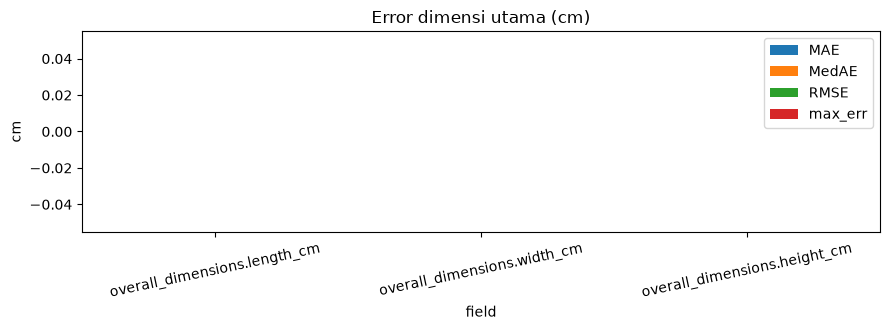

In [6]:
import pandas as pd

# Sejak evaluate.py membedakan satuan, kunci toleransi field cm ("+-0.5"/"+-1.0")
# berbeda dengan field mm ("+-1.0"/"+-2.0"), jadi diambil berdasarkan urutan:
# elemen pertama = ambang ketat, terakhir = ambang longgar.
rows_num = []
for path, s in report.numeric.items():
    if not s["n"]:
        continue
    tols = list(s["tolerance"].items())
    (k_ketat, t_ketat), (k_longgar, t_longgar) = tols[0], tols[-1]
    unit = s.get("unit", "cm")
    rows_num.append({
        "field": path,
        "n": s["n"],
        "MAE": s["mae"],
        "MedAE": s["medae"],
        "RMSE": s["rmse"],
        "max_err": s["max_err"],
        "bias": s["bias"],
        "exact": s["n_exact"],
        "toleransi": f"{k_ketat} / {k_longgar} {unit}",
        "err_ketat": t_ketat["n_error"],
        "acc_ketat%": t_ketat["accuracy_pct"],
        "err_longgar": t_longgar["n_error"],
        "acc_longgar%": t_longgar["accuracy_pct"],
        "null_hilang": s["n_pred_missing"],
        "null_mengarang": s["n_pred_extra"],
    })

df_num = pd.DataFrame(rows_num).set_index("field")
display(df_num)

dim = [p for p in df_num.index if p.startswith("overall_dimensions")]
if dim:
    ax = df_num.loc[dim, ["MAE", "MedAE", "RMSE", "max_err"]].plot.bar(
        figsize=(9, 3.4), title="Error dimensi utama (cm)", rot=12)
    ax.set_ylabel("cm"); plt.tight_layout(); plt.show()


### 6b. Sebaran error dimensi

Histogram lebih jujur daripada rata-rata: MAE 0.6 cm bisa berarti "semua meleset 0.6 cm"
atau "95 % tepat, 5 % meleset 12 cm". Yang kedua jauh lebih berbahaya.

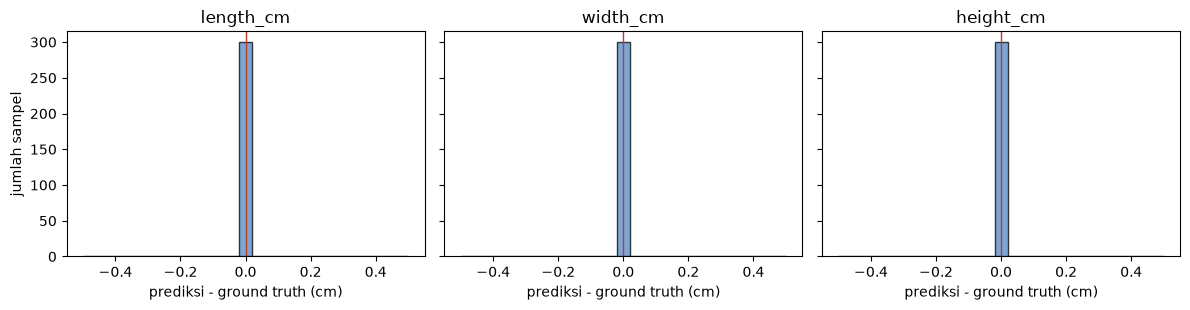

Sampel dengan error panjang > 1 cm: 0
[]


In [7]:
valid_pairs = []
for sid, raw in preds.items():
    if sid not in refs:
        continue
    o = ev.parse_prediction(sid, raw)
    if o.ok:
        valid_pairs.append((sid, o.data, refs[sid]))

fields = ["overall_dimensions.length_cm", "overall_dimensions.width_cm",
          "overall_dimensions.height_cm"]
fig, axes = plt.subplots(1, len(fields), figsize=(4 * len(fields), 3.2), sharey=True)
for ax, path in zip(axes, fields):
    errs = [ev._get(p, path) - ev._get(r, path)
            for _, p, r in valid_pairs
            if ev._get(p, path) is not None and ev._get(r, path) is not None]
    ax.hist(errs, bins=25, color="#7ba7d7", edgecolor="#333")
    ax.axvline(0, color="#c0392b", lw=1)
    ax.set_title(path.split(".")[-1]); ax.set_xlabel("prediksi - ground truth (cm)")
axes[0].set_ylabel("jumlah sampel")
plt.tight_layout(); plt.show()

over = [(sid, round(ev._get(p, "overall_dimensions.length_cm") - ev._get(r, "overall_dimensions.length_cm"), 2))
        for sid, p, r in valid_pairs
        if abs((ev._get(p, "overall_dimensions.length_cm") or 0) - ev._get(r, "overall_dimensions.length_cm")) > 1.0]
print(f"Sampel dengan error panjang > 1 cm: {len(over)}")
print(over[:15])

## 7. Partisi, kategorikal, dan drop pocket

Angka partisi (ambalan/pintu/laci) tidak boleh dinilai dengan MAE saja - salah satu ambalan
berarti part list ikut salah. Karena itu dilaporkan **distribusi off-by-N**.

In [8]:
# reindex: field yang tidak punya sampel hanya berisi {"n": 0}, tanpa kolom lain.
df_cnt = pd.DataFrame(report.counts).T.reindex(
    columns=["n", "n_correct", "n_error", "exact_match_pct", "mae"])
display(df_cnt)

print("Distribusi selisih (prediksi - ground truth):")
for path, s in report.counts.items():
    if s.get("n"):
        print(f"  {path:<32} {s['off_by']}")

df_cat = pd.DataFrame(report.categorical).T.reindex(
    columns=["n", "n_correct", "n_error", "accuracy_pct"])
display(df_cat)

print("Kesalahan kategorikal paling sering:")
for path, s in report.categorical.items():
    for pair, n in s["top_confusions"].items():
        print(f"  {path:<30} {pair}  x{n}")

if report.drop_pocket:
    d = report.drop_pocket
    print(f"\nDrop pocket - TP={d['tp']} FP={d['fp']} FN={d['fn']} TN={d['tn']} "
          f"| total error={d['n_error']} | precision={d['precision']:.3f} "
          f"recall={d['recall']:.3f} f1={d['f1']:.3f}")

,n,n_correct,n_error,exact_match_pct,mae
partitions.shelves_count,300,268,32,89.33,0.1067
partitions.doors_count,300,299,1,99.67,0.0033
partitions.drawers_count,300,297,3,99.0,0.01


Distribusi selisih (prediksi - ground truth):
  partitions.shelves_count         {-1: 16, 0: 268, 1: 16}
  partitions.doors_count           {-1: 1, 0: 299}
  partitions.drawers_count         {-1: 1, 0: 297, 1: 2}


,n,n_correct,n_error,accuracy_pct
furniture_type,300,300,0,100.0
plinth.has_plinth,300,300,0,100.0
has_curve,300,300,0,100.0
material.board_material,300,300,0,100.0
material.finish,300,300,0,100.0
material.finish_color,300,300,0,100.0
material.finish_code,300,300,0,100.0


Kesalahan kategorikal paling sering:

Drop pocket - TP=72 FP=0 FN=0 TN=228 | total error=0 | precision=1.000 recall=1.000 f1=1.000


## 8. Breakdown per kelompok

Kalau satu jenis furnitur atau satu layout jauh lebih buruk dari yang lain, itu masalah
data - bukan masalah kapasitas model. Solusinya menambah sampel di kelompok tersebut,
bukan menambah epoch.

[furniture_type]


,n,dim_mae_cm,count_errors,type_accuracy_pct
base_cabinet,88.0,0.0,11.0,100.0
bookshelf,81.0,0.0,14.0,100.0
nightstand,31.0,0.0,0.0,100.0
reception_desk,100.0,0.0,11.0,100.0


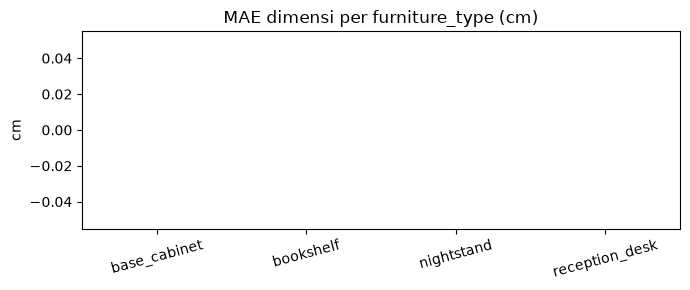

[layout]


,n,dim_mae_cm,count_errors,type_accuracy_pct
isometric,159.0,0.0,32.0,100.0
multiview_2d,141.0,0.0,4.0,100.0


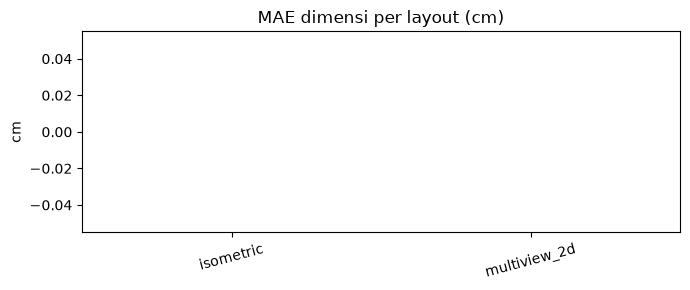

In [9]:
for gname, buckets in report.by_group.items():
    if not buckets:
        continue
    df_g = pd.DataFrame(buckets).T
    print(f"[{gname}]")
    display(df_g)
    if "dim_mae_cm" in df_g and df_g["dim_mae_cm"].notna().any():
        ax = df_g["dim_mae_cm"].plot.bar(figsize=(7, 3), rot=15,
                                         title=f"MAE dimensi per {gname} (cm)", color="#8fcf9a")
        ax.set_ylabel("cm"); plt.tight_layout(); plt.show()

## 9. Dampak hilir: apakah errornya benar-benar merugikan?

Error 0.3 cm pada tinggi total mungkin tidak mengubah satu pun ukuran potong,
sedangkan salah hitung ambalan menambah satu panel. Bagian ini menjalankan
`bom_engine` pada prediksi **dan** ground truth lalu membandingkan part list-nya.

In [10]:
d = report.downstream
if d.get("n"):
    display(pd.Series({
        "sampel dibandingkan": d["n"],
        "part list identik": f"{d['partlist_identical']} ({d['partlist_identical_pct']:.2f} %)",
        "MAE jumlah keping": d["piece_count_mae"],
        "sampel jumlah keping meleset": d["piece_count_error_samples"],
        "MAE ukuran potong (mm)": d["part_dim_mae_mm"],
        "sisi meleset > 2 mm": f"{d['part_dim_error_gt_2mm']} dari {d['part_dim_checked']}",
        "MAE jumlah lembar": d["sheet_count_mae"],
        "sampel jumlah lembar meleset": d["sheet_count_error_samples"],
        "sampel part tak muat lembaran": d.get("unplaced_samples", 0),
    }, name="nilai").to_frame())
    print("Part hilang di prediksi :", d["missing_parts_top"])
    print("Part berlebih           :", d["extra_parts_top"])
else:
    print("Tidak ada sampel valid untuk dibandingkan.")

,nilai
sampel dibandingkan,300
part list identik,261 (87.00 %)
MAE jumlah keping,0.17
sampel jumlah keping meleset,36
MAE ukuran potong (mm),0.147
sisi meleset > 2 mm,7 dari 5324
MAE jumlah lembar,0.053
sampel jumlah lembar meleset,16
sampel part tak muat lembaran,0


Part hilang di prediksi : {'Shelf': 2, 'Drawer Front': 1, 'Drawer Box Front/Back': 1, 'Drawer Bottom': 1, 'Drawer Box Side': 1}
Part berlebih           : {'Shelf': 1}


## 10. Periksa sampel terburuk secara manual

Skor error gabungan = jumlah selisih numerik (cm) + 3x selisih partisi + 2x salah kategorikal.
Buka gambarnya dan bandingkan sendiri - biasanya ketahuan polanya (angka tertimpa garis,
koma desimal, atau dimensi yang memang tidak terbaca di sketsa).

synth_1196  skor error = 3.0  layout=isometric
  partitions.drawers_count           prediksi=2                  seharusnya=1


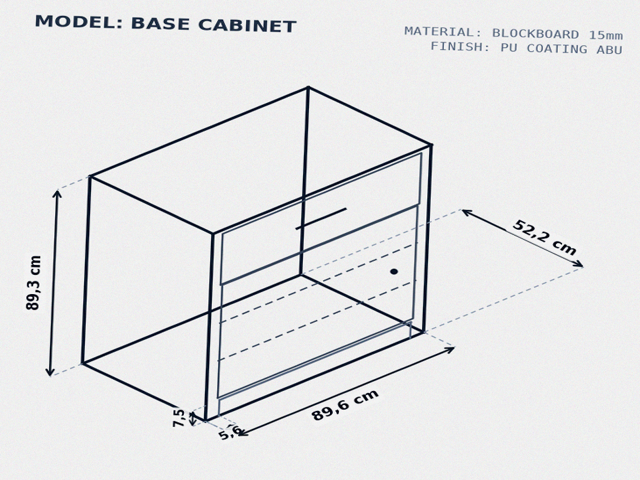

synth_0737  skor error = 3.0  layout=isometric
  partitions.shelves_count           prediksi=6                  seharusnya=5


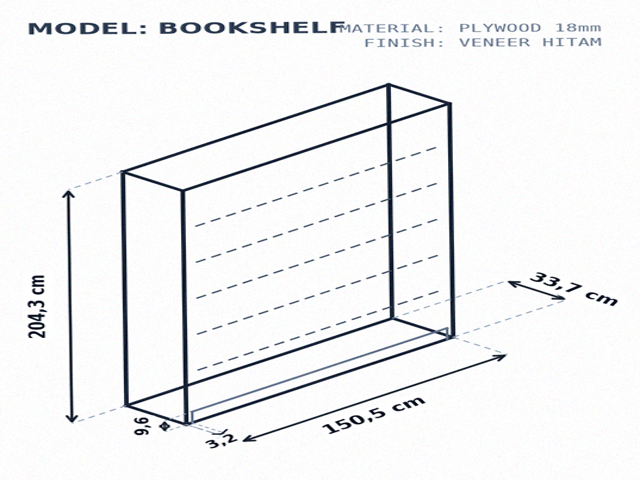

synth_0939  skor error = 3.0  layout=isometric
  partitions.shelves_count           prediksi=0                  seharusnya=1


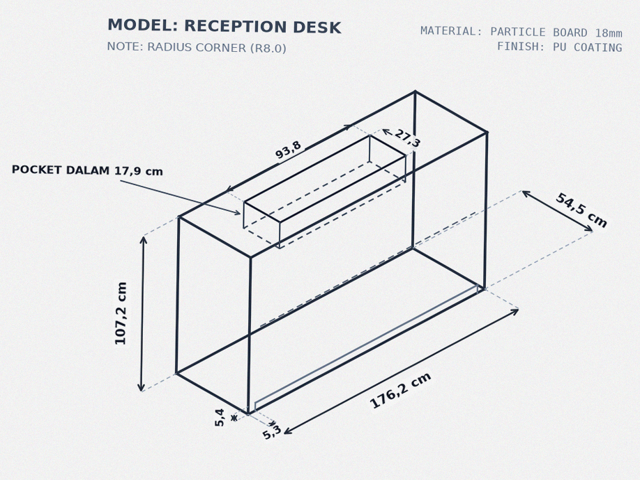

In [11]:
from PIL import Image

TOP_N = 3
for s in report.worst_samples[:TOP_N]:
    sid = s["id"]
    row = next((r for r in rows if r["id"] == sid), None)
    if row is None:
        continue
    img_path = ev.image_path_of(row, DATA_DIR)
    print("=" * 70)
    print(f"{sid}  skor error = {s['error_score']}  layout={meta.get(sid, {}).get('layout')}")
    out = ev.parse_prediction(sid, preds[sid])
    if out.ok:
        for path in ev.NUMERIC_FIELDS + ev.COUNT_FIELDS + ev.CATEGORICAL_FIELDS:
            p, r = ev._get(out.data, path), ev._get(refs[sid], path)
            if p != r:
                print(f"  {path:<34} prediksi={p!r:<18} seharusnya={r!r}")
    else:
        print(f"  GAGAL PARSE: {out.error_kind} - {out.error_detail}")
    if img_path and img_path.exists():
        display(Image.open(img_path).resize((640, 480)))

## 11. Gold Test - foto sketsa nyata dari bengkel

Data sintetis membuktikan model bisa membaca gambar buatan matplotlib.
Yang menentukan layak-tidaknya dipakai adalah **foto gambar tangan/print dari bengkel**.

Taruh foto di `gold_test/images/` dan (kalau ada) label manual di `gold_test/ground_truth/<nama>.json`
dengan skema yang sama. Tanpa label pun tetap berguna: output tetap dicek validitas skemanya
dan bisa dibaca manual.

In [12]:
GOLD_DIR = BASE_DIR / "gold_test"
GOLD_IMG = GOLD_DIR / "images"
GOLD_GT  = GOLD_DIR / "ground_truth"
RUN_GOLD = GOLD_IMG.exists() and any(GOLD_IMG.iterdir()) if GOLD_IMG.exists() else False

if not RUN_GOLD:
    GOLD_IMG.mkdir(parents=True, exist_ok=True)
    GOLD_GT.mkdir(parents=True, exist_ok=True)
    print(f"Belum ada foto gold test. Taruh file di: {GOLD_IMG}")
else:
    if not RUN_INFERENCE:
        model, processor = ev.load_model(ADAPTER_DIR, MODEL_ID, MIN_PIXELS, MAX_PIXELS)

    gold_preds, gold_report = ev.gold_test(
        GOLD_IMG, model, processor, MIN_PIXELS, MAX_PIXELS,
        gt_dir=GOLD_GT if any(GOLD_GT.glob("*.json")) else None,
        max_new_tokens=MAX_NEW_TOKENS,
    )

    n_ok = sum(ev.parse_prediction(k, v).ok for k, v in gold_preds.items())
    print(f"Schema validity di foto nyata: {n_ok}/{len(gold_preds)} "
          f"({100 * n_ok / max(len(gold_preds), 1):.1f} %)\n")

    for sid, raw in gold_preds.items():
        out = ev.parse_prediction(sid, raw)
        print("=" * 70)
        print(sid, "->", "VALID" if out.ok else f"GAGAL ({out.error_kind}: {out.error_detail})")
        print(json.dumps(out.data, indent=2)[:700] if out.ok else raw[:300])

    if gold_report is not None:
        print(ev.format_report(gold_report))

Belum ada foto gold test. Taruh file di: d:\Codelabs\TukangKayu\Nesto.ai\AI Services\gold_test\images


## 12. Kriteria kelulusan

| Kriteria | Target | Kalau belum tercapai |
|---|---|---|
| Schema Validity Rate | > 98 % | naikkan `max_new_tokens` (JSON kepotong), tambah epoch, atau paksa lewat constrained decoding |
| MAE dimensi utama | < 1.0 cm | naikkan `MAX_PIXELS` - angka pada sketsa terlalu kecil untuk dibaca |
| Exact match partisi | > 95 % | tambah variasi jumlah ambalan/pintu/laci di dataset |
| `sheet_count_error_samples` | mendekati 0 | error yang tersisa tidak mengubah kebutuhan bahan |
| Gold test | semua output valid & angka masuk akal | tambah augmentasi foto (blur, bayangan, miring) ke generator |